In [44]:
# Importando Librerias
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

In [45]:
# Fórmula real: C = (F - 32) * 5/9

celsius = np.array([
    -40.0, -37.2, -34.4, -31.6, -28.8, -26.0, -23.2, -20.4, -17.6,
    -14.8, -12.0, -9.2, -6.4, -3.6, -0.8, 2.0, 4.8, 7.6,
    10.4, 13.2, 16.0, 18.8, 21.6, 24.4, 27.2, 30.0, 32.8,
    35.6, 38.4, 41.2, 44.0, 46.8, 49.6, 52.4, 55.2, 58.0,
    60.8, 63.6, 66.4, 69.2, 72.0, 74.8, 77.6, 80.4, 83.2,
    86.0, 88.8, 91.6, 94.4, 97.2, 100.0
], dtype=float)

fahrenheit = np.array([
    -40.0, -34.96, -29.92, -24.88, -19.84, -14.8, -9.76, -4.72, 0.32,
    5.36, 10.4, 15.44, 20.48, 25.52, 30.56, 35.6, 40.64, 45.68,
    50.72, 55.76, 60.8, 65.84, 70.88, 75.92, 80.96, 86.0, 91.04,
    96.08, 101.12, 106.16, 111.2, 116.24, 121.28, 126.32, 131.36, 136.4,
    141.44, 146.48, 151.52, 156.56, 161.6, 166.64, 171.68, 176.72, 181.76,
    186.8, 191.84, 196.88, 201.92, 206.96, 212.0
], dtype=float)

for c,f in zip(celsius, fahrenheit):
    print(f'{c}ºC = {f}ºF')

-40.0ºC = -40.0ºF
-37.2ºC = -34.96ºF
-34.4ºC = -29.92ºF
-31.6ºC = -24.88ºF
-28.8ºC = -19.84ºF
-26.0ºC = -14.8ºF
-23.2ºC = -9.76ºF
-20.4ºC = -4.72ºF
-17.6ºC = 0.32ºF
-14.8ºC = 5.36ºF
-12.0ºC = 10.4ºF
-9.2ºC = 15.44ºF
-6.4ºC = 20.48ºF
-3.6ºC = 25.52ºF
-0.8ºC = 30.56ºF
2.0ºC = 35.6ºF
4.8ºC = 40.64ºF
7.6ºC = 45.68ºF
10.4ºC = 50.72ºF
13.2ºC = 55.76ºF
16.0ºC = 60.8ºF
18.8ºC = 65.84ºF
21.6ºC = 70.88ºF
24.4ºC = 75.92ºF
27.2ºC = 80.96ºF
30.0ºC = 86.0ºF
32.8ºC = 91.04ºF
35.6ºC = 96.08ºF
38.4ºC = 101.12ºF
41.2ºC = 106.16ºF
44.0ºC = 111.2ºF
46.8ºC = 116.24ºF
49.6ºC = 121.28ºF
52.4ºC = 126.32ºF
55.2ºC = 131.36ºF
58.0ºC = 136.4ºF
60.8ºC = 141.44ºF
63.6ºC = 146.48ºF
66.4ºC = 151.52ºF
69.2ºC = 156.56ºF
72.0ºC = 161.6ºF
74.8ºC = 166.64ºF
77.6ºC = 171.68ºF
80.4ºC = 176.72ºF
83.2ºC = 181.76ºF
86.0ºC = 186.8ºF
88.8ºC = 191.84ºF
91.6ºC = 196.88ºF
94.4ºC = 201.92ºF
97.2ºC = 206.96ºF
100.0ºC = 212.0ºF


In [46]:
# Crear la red neuronal
modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)


In [47]:
# Arquitectura del modelo
modelo.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Entrenando la red neuronal

print('Comenzando entrenamiento...')
historial = modelo.fit(celsius, fahrenheit, epochs=500, verbose=False)
print('Modelo entrenado!')


Comenzando entrenamiento...
Modelo entrenado!


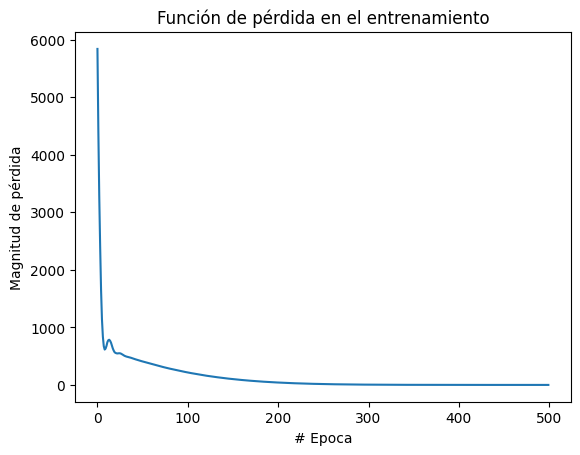

In [49]:
# Graficar la funcion de perdida

plt.xlabel('# Epoca')
plt.ylabel('Magnitud de pérdida')
plt.title('Función de pérdida en el entrenamiento')
plt.plot(historial.history['loss'])



In [50]:
# Pesos aprendidos por la red
capa = modelo.layers[0]
peso = capa.get_weights()

print(f"Peso (W): {peso[0][0][0]:.4f}")
print(f"Sesgo (b): {peso[1][0]:.4f}")

Peso (W): 1.8015
Sesgo (b): 31.8714


In [51]:
print(f"Formula Aprendida por la red")
print(f"Celsius = {peso[0][0][0]:.4f} * Fahrenheit + {peso[1][0]:.4f}")

Formula Aprendida por la red
Celsius = 1.8015 * Fahrenheit + 31.8714


In [54]:
# Probar la red neuronal
tmp_usuario = 100

resultado = modelo.predict(np.array([tmp_usuario]), verbose=0)[0][0]

print(f"Temperatura en Celsius: {tmp_usuario}")
print(f"Temperatura en Fahrenheit: {resultado:.2f}")

Temperatura en Celsius: 100
Temperatura en Fahrenheit: 212.02
